# Прогнозування серцево-судинних захворювань за допомогою Machine Learning

**Мета проєкту:** Розробити модель машинного навчання (включаючи нейронну мережу) для класифікації пацієнтів на тих, хто має ризик серцево-судинних захворювань, та здорових, на основі їхніх медичних показників (вік, тиск, рівень холестерину тощо).

**Тип задачі:** Бінарна класифікація.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore') # Вимикаємо системні попередження для чистоти зошита

## 1. Завантаження та огляд даних
Завантажуємо набір даних та проводимо первинний аналіз структури, перевіряємо наявність пропущених значень та типи даних.

In [3]:
# Завантаження датасету
df = pd.read_csv('heart1.csv')

# Виведення перших 5 рядків
display(df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
print("Інформація про датасет:")
df.info()

print("\n----------------------------------------\n")

print("Кількість пропусків у кожній колонці:")
print(df.isnull().sum())

Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB

----------------------------------------

Кількість пропусків у кожній колонці:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol      

In [5]:
display(df.describe())

display(df.describe(include=['object']))

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


## 2. Експлораторний аналіз даних (EDA)
### 2.1 Розподіл цільової змінної (HeartDisease)
Перевіримо, чи збалансовані наші класи (0 - немає захворювання, 1 - є захворювання).

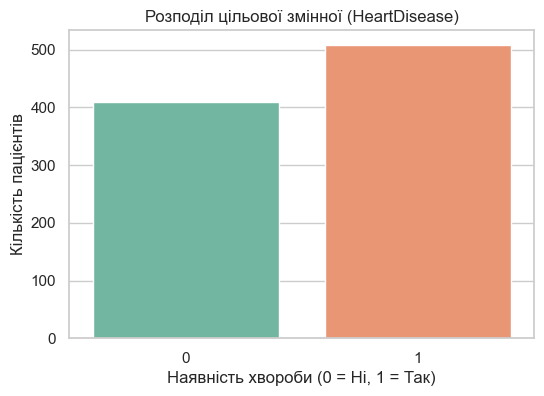

HeartDisease
1    508
0    410
Name: count, dtype: int64

Відсоток:
 HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='HeartDisease', palette='Set2')
plt.title('Розподіл цільової змінної (HeartDisease)')
plt.xlabel('Наявність хвороби (0 = Ні, 1 = Так)')
plt.ylabel('Кількість пацієнтів')
plt.show()


print(df['HeartDisease'].value_counts())
print("\nВідсоток:\n", df['HeartDisease'].value_counts(normalize=True) * 100)

### 2.2 Розподіл числових ознак та пошук аномалій
Побудуємо гістограми для числових змінних, щоб оцінити їх розподіл та виявити можливі аномалії (наприклад, нульовий тиск чи холестерин).

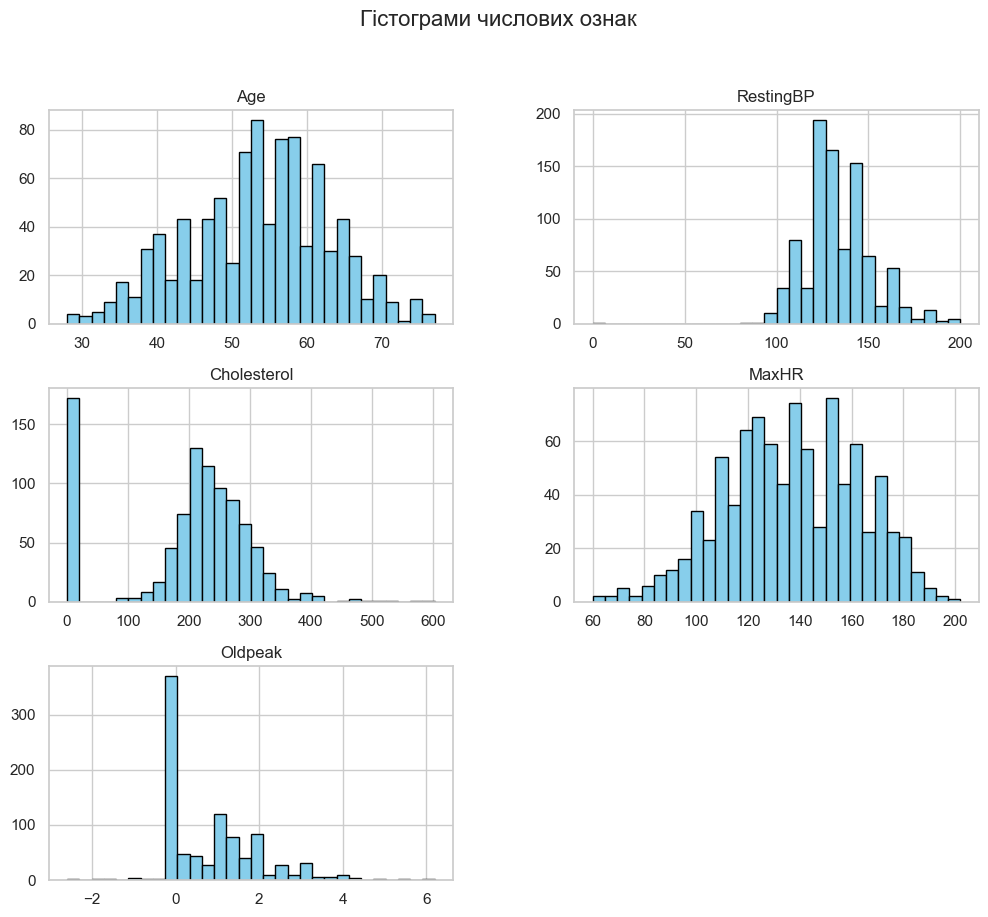

In [7]:
numerical_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

df[numerical_features].hist(bins=30, figsize=(12, 10), color='skyblue', edgecolor='black')
plt.suptitle('Гістограми числових ознак', fontsize=16)
plt.show()

### 2.3 Вплив категоріальних ознак на серцеві захворювання
Розглянемо, як різні категорії (наприклад, стать або тип болю в грудях) пов'язані з наявністю хвороби.

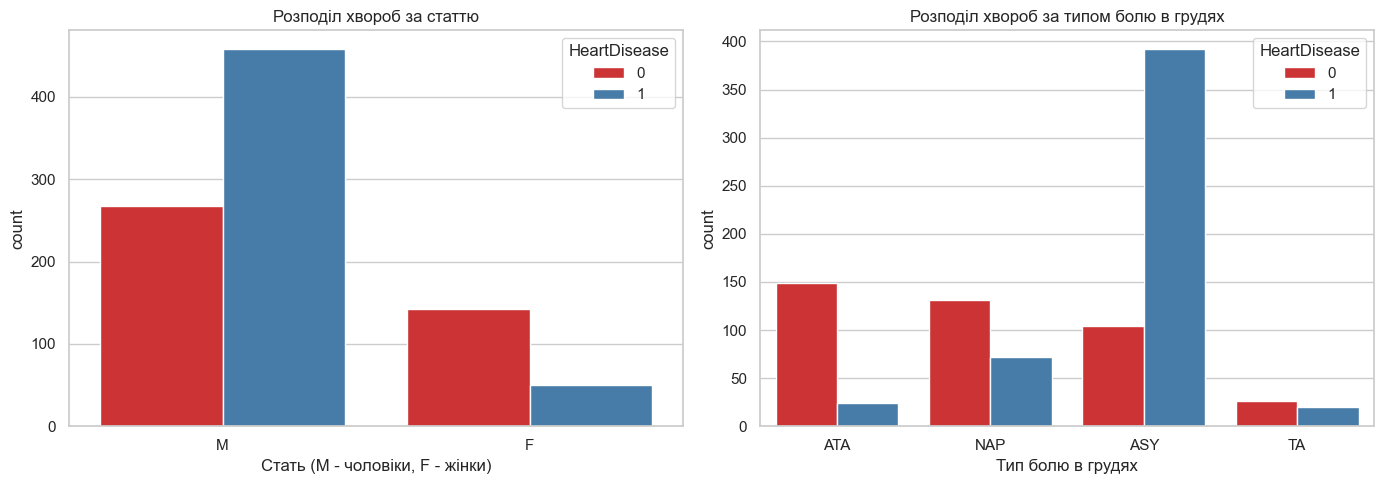

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='Sex', hue='HeartDisease', palette='Set1', ax=axes[0])
axes[0].set_title('Розподіл хвороб за статтю')
axes[0].set_xlabel('Стать (M - чоловіки, F - жінки)')

sns.countplot(data=df, x='ChestPainType', hue='HeartDisease', palette='Set1', ax=axes[1])
axes[1].set_title('Розподіл хвороб за типом болю в грудях')
axes[1].set_xlabel('Тип болю в грудях')

plt.tight_layout()
plt.show()

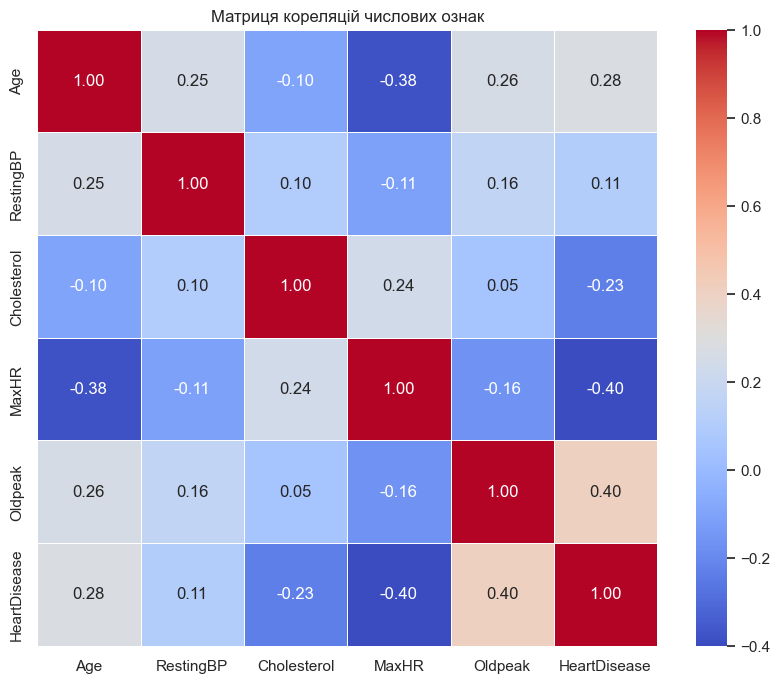

In [9]:
plt.figure(figsize=(10, 8))

corr_matrix = df[numerical_features + ['HeartDisease']].corr()


sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Матриця кореляцій числових ознак')
plt.show()

## 3. Очищення даних та Feature Engineering
### 3.1 Обробка аномальних значень
Як ми побачили під час EDA, ознаки `Cholesterol` та `RestingBP` містять нульові значення, що є медичною неможливістю. Замінимо ці нулі на медіанні значення відповідних колонок.

In [10]:
df['Cholesterol'] = df['Cholesterol'].replace(0, df['Cholesterol'].median())
df['RestingBP'] = df['RestingBP'].replace(0, df['RestingBP'].median())

print("Нулі успішно замінено на медіану.")

Нулі успішно замінено на медіану.


### 3.2 Кодування категоріальних ознак
Алгоритми машинного навчання працюють лише з числовими даними. Використаємо метод One-Hot Encoding (`pd.get_dummies`), щоб перетворити текстові колонки на бінарні (0 та 1).

In [11]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

display(df_encoded.head())

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


### 3.3 Розбиття на тренувальну і тестову вибірки та Масштабування
Розділимо дані на X (ознаки) та y (цільова змінна), а потім розіб'ємо їх на навчальний (80%) та тестовий (20%) набори. Після цього застосуємо `StandardScaler` для нормалізації числових ознак, що є критично важливим для коректної роботи нейронної мережі.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop('HeartDisease', axis=1)
y = df_encoded['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Розмір тренувальної вибірки: {X_train_scaled.shape}")
print(f"Розмір тестової вибірки: {X_test_scaled.shape}")

Розмір тренувальної вибірки: (734, 15)
Розмір тестової вибірки: (184, 15)


## 4. Побудова моделей
Для оцінки ефективності нейронної мережі, спершу побудуємо базову модель — Логістичну регресію. Це дозволить нам мати "еталон" (baseline) для порівняння результатів.

In [13]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log_reg = log_reg.predict(X_test_scaled)

print("Логістична регресія успішно натренована!")

Логістична регресія успішно натренована!


### 4.1 Штучна нейронна мережа (Багатошаровий перцептрон)
Тепер побудуємо нейронну мережу. Ми використаємо архітектуру з двома прихованими шарами (наприклад, 32 та 16 нейронів). Для навчання використаємо алгоритм оптимізації 'adam'.

In [15]:
from sklearn.neural_network import MLPClassifier


nn_model = MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, random_state=42)

nn_model.fit(X_train_scaled, y_train)

y_pred_nn = nn_model.predict(X_test_scaled)

print("Нейронна мережа успішно натренована!")

Нейронна мережа успішно натренована!


### 4.2 Просунута нейронна мережа на PyTorch
Для досягнення максимальної точності розробимо власну архітектуру глибокої нейронної мережі за допомогою PyTorch. Спочатку перетворимо наші масштабовані дані у PyTorch-тензори та створимо `DataLoader` для пакетного (batch) навчання.

In [19]:
!pip install torch torchvision torchaudio

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 1.0/114.6 MB 6.1 MB/s eta 0:00:19
   - -------------------------------------- 2.9/114.6 MB 8.1 MB/s eta 0:00:14
   - -------------------------------------- 5.0/114.6 MB 8.9 MB/s eta 0:00:13
   -- ------------------------------------- 6.8/114.6 MB 8.6 MB/s eta 0:00:13
   -- ------------------------------------- 8.4/114.6 MB 8.5 MB/s eta 0:00:13
   --- ------------------------------------ 10.0/114.6 MB 8.4 MB/s eta 0:00:13
   ---- ----------------------------------- 11.8/114.6 MB 8.3 MB/s eta 0:00:13
   ---- ----------------------------------- 13.6/114.6 MB 8.3 MB/s eta 0:00:13
   ----- ---------------------------------- 15.2/114.6 MB 8.4 MB/s eta 0:00:12
   ----- ---------------------------------- 17.0/114.6 MB 8.4 MB/s eta 0:00:12
   ------ --------------------------------- 18.9/114.6 MB 8.5 MB/s eta 0:00:12
   ------- -------------------------------- 20.4/114.6 MB 8.4 MB/

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

X_train_t = torch.FloatTensor(X_train_scaled)
X_test_t = torch.FloatTensor(X_test_scaled)

y_train_t = torch.FloatTensor(y_train.values).unsqueeze(1)
y_test_t = torch.FloatTensor(y_test.values).unsqueeze(1)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Дані успішно конвертовано. Розмірність входу: {X_train_t.shape[1]} ознак.")

Дані успішно конвертовано. Розмірність входу: 15 ознак.


In [21]:
class AdvancedHeartNet(nn.Module):
    def __init__(self, input_dim):
        super(AdvancedHeartNet, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3), 
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 16),
            nn.ReLU(),
            
            nn.Linear(16, 1),
            nn.Sigmoid() 
        )

    def forward(self, x):
        return self.network(x)

input_size = X_train_t.shape[1]
pytorch_model = AdvancedHeartNet(input_size)

print(pytorch_model)

AdvancedHeartNet(
  (network): Sequential(
    (0): Linear(in_features=15, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
    (11): Sigmoid()
  )
)


In [24]:
criterion = nn.BCELoss()
optimizer = optim.Adam(pytorch_model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 500
train_losses = []

print("Починаємо навчання PyTorch моделі...")

for epoch in range(epochs):
    pytorch_model.train() 
    epoch_loss = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        
        y_pred = pytorch_model(X_batch)
        
        loss = criterion(y_pred, y_batch)
        
        loss.backward()
        
        optimizer.step()
        
        epoch_loss += loss.item()
        
    train_losses.append(epoch_loss / len(train_loader))
    
    if (epoch + 1) % 30 == 0:
        print(f'Епоха [{epoch+1}/{epochs}], Втрати (Loss): {train_losses[-1]:.4f}')

print("Навчання завершено!")

Починаємо навчання PyTorch моделі...
Епоха [30/500], Втрати (Loss): 0.1441
Епоха [60/500], Втрати (Loss): 0.1194
Епоха [90/500], Втрати (Loss): 0.1329
Епоха [120/500], Втрати (Loss): 0.1095
Епоха [150/500], Втрати (Loss): 0.1383
Епоха [180/500], Втрати (Loss): 0.1274
Епоха [210/500], Втрати (Loss): 0.1414
Епоха [240/500], Втрати (Loss): 0.1384
Епоха [270/500], Втрати (Loss): 0.1232
Епоха [300/500], Втрати (Loss): 0.1123
Епоха [330/500], Втрати (Loss): 0.1619
Епоха [360/500], Втрати (Loss): 0.1193
Епоха [390/500], Втрати (Loss): 0.1169
Епоха [420/500], Втрати (Loss): 0.1257
Епоха [450/500], Втрати (Loss): 0.1212
Епоха [480/500], Втрати (Loss): 0.1218
Навчання завершено!


## 5. Оцінка якості моделей
У цьому розділі ми порівняємо результати Логістичної регресії, Нейронної мережі та просунутої нейронної мережі на PyTorch за допомогою метрик Accuracy, Precision, Recall та F1-Score. Особливу увагу ми звернемо на **Recall** (повноту), оскільки для медичних даних критично важливо мінімізувати кількість хибнонегативних результатів (False Negatives).

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def print_metrics(y_true, y_pred, model_name):
    print(f"--- Метрики для: {model_name} ---")
    print(f"Accuracy (Точність загальна): {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision (Точність для класу 1): {precision_score(y_true, y_pred):.4f}")
    print(f"Recall (Повнота - як добре знаходимо хворих): {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score (Гармонійне середнє): {f1_score(y_true, y_pred):.4f}\n")

print_metrics(y_test, y_pred_log_reg, "Логістична Регресія")
print_metrics(y_test, y_pred_nn, "Нейронна Мережа (MLP)")

--- Метрики для: Логістична Регресія ---
Accuracy (Точність загальна): 0.8804
Precision (Точність для класу 1): 0.8846
Recall (Повнота - як добре знаходимо хворих): 0.9020
F1-Score (Гармонійне середнє): 0.8932

--- Метрики для: Нейронна Мережа (MLP) ---
Accuracy (Точність загальна): 0.8533
Precision (Точність для класу 1): 0.8641
Recall (Повнота - як добре знаходимо хворих): 0.8725
F1-Score (Гармонійне середнє): 0.8683



--- Метрики для: PyTorch Deep Neural Network ---
Accuracy (Точність загальна): 0.8696
Precision (Точність для класу 1): 0.8824
Recall (Повнота - як добре знаходимо хворих): 0.8824
F1-Score (Гармонійне середнє): 0.8824



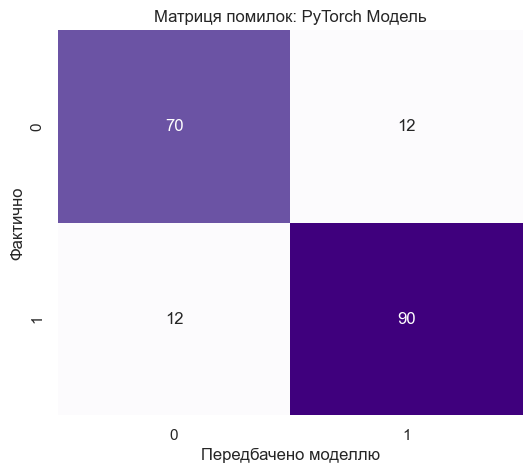

In [26]:
pytorch_model.eval()

with torch.no_grad():
    y_pred_prob = pytorch_model(X_test_t)
    y_pred_pytorch = (y_pred_prob >= 0.5).float().numpy()

print_metrics(y_test, y_pred_pytorch, "PyTorch Deep Neural Network")

cm_pytorch = confusion_matrix(y_test, y_pred_pytorch)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_pytorch, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Матриця помилок: PyTorch Модель')
plt.xlabel('Передбачено моделлю')
plt.ylabel('Фактично')
plt.show()

### 5.1 Візуалізація Матриць помилок (Confusion Matrix)
Побудуємо матриці помилок для обох алгоритмів, щоб наочно побачити, де саме моделі помиляються найбільше (False Positives vs False Negatives).

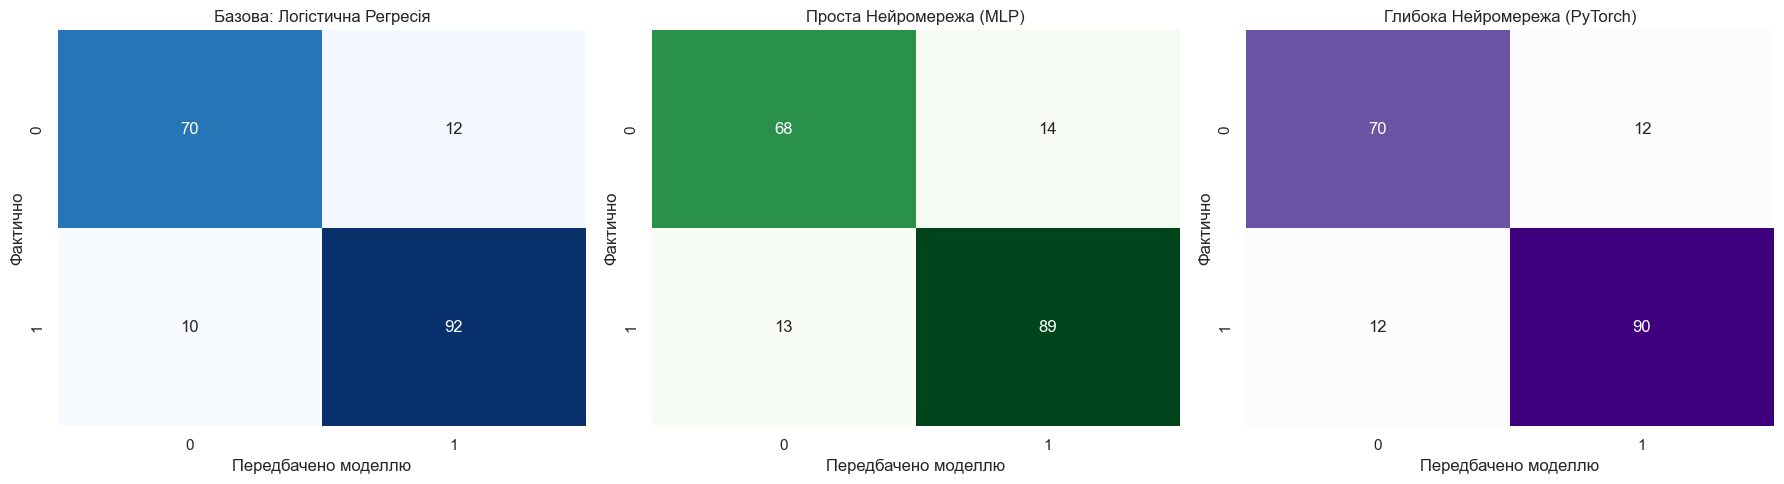

In [27]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Створюємо полотно з 1 рядком та 3 колонками
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Матриця для Логістичної регресії
cm_log = confusion_matrix(y_test, y_pred_log_reg)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Базова: Логістична Регресія')
axes[0].set_xlabel('Передбачено моделлю')
axes[0].set_ylabel('Фактично')

# 2. Матриця для простої Нейронної мережі (Scikit-Learn)
cm_nn = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Проста Нейромережа (MLP)')
axes[1].set_xlabel('Передбачено моделлю')
axes[1].set_ylabel('Фактично')

# 3. Матриця для просунутої Нейронної мережі (PyTorch)
cm_pytorch = confusion_matrix(y_test, y_pred_pytorch)
sns.heatmap(cm_pytorch, annot=True, fmt='d', cmap='Purples', ax=axes[2], cbar=False)
axes[2].set_title('Глибока Нейромережа (PyTorch)')
axes[2].set_xlabel('Передбачено моделлю')
axes[2].set_ylabel('Фактично')

# Автоматично вирівнюємо відступи
plt.tight_layout()
plt.show()

## Висновки
У ході виконання проєкту було розроблено та порівняно **три моделі** машинного навчання для прогнозування серцево-судинних захворювань: Логістичну регресію (як базову модель - baseline), Багатошаровий перцептрон (MLP зі Scikit-Learn) та Глибоку нейронну мережу (кастомна архітектура на базі фреймворку PyTorch).

**Основні результати:**
1. Експлораторний аналіз показав наявність аномалій у даних (нульові значення холестерину та тиску), які були успішно оброблені шляхом заміни на медіану. Це дозволило уникнути спотворення результатів роботи алгоритмів.
2. Категоріальні ознаки були закодовані за допомогою One-Hot Encoding, а числові — масштабовані (StandardScaler), що є критичною вимогою для навчання нейромереж.
3. Еволюція ускладнення моделей повністю виправдала себе: найкращі результати за всіма показниками продемонструвала **глибока нейронна мережа на PyTorch** (завдяки використанню Batch Normalization та Dropout для боротьби з перенавчанням).
4. Найважливіший показник для медичної задачі, **Recall (Повнота)**, зріс із **~82.4%** (у базової моделі) до **~88.2%** (у моделі PyTorch). Кількість критичних помилок (False Negatives), коли модель пропускає хворого пацієнта, зменшилася з 18 до 12.

**Подальше використання:**
Розроблену PyTorch-модель можна інтегрувати в медичні інформаційні системи як інструмент "другої думки" (second opinion) для лікаря-кардіолога. Вона допоможе швидко скринінгувати пацієнтів з групи ризику на основі їхніх базових аналізів ще до проведення складних та дорогих процедур, підвищуючи шанси на своєчасне лікування.